In [1]:
from pathlib import Path
import os, json, math, random
import numpy as np
import pandas as pd
from PIL import Image

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets as tvds, transforms
from torchvision import models as tvm
from torchvision.models import ResNet18_Weights

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
from torchmetrics.classification import MulticlassAUROC, MulticlassAccuracy
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import mplcyberpunk, matplotlib.patheffects as pe
plt.style.use("cyberpunk")

In [16]:
REPO_ROOT = Path.cwd().parents[1] if (Path.cwd().name=="classification" and Path.cwd().parent.name=="notebooks") else Path.cwd()
RAW_ROOT  = REPO_ROOT / "data" / "downloads" / "classification" / "leukemia_classification"
PROC_ROOT = REPO_ROOT / "data" / "processed" / "classification" / "leukemia_classification_processed"
SPLIT_TAG = "train_f012__val_prelim"  # just a descriptive name
SPLIT_DIR = PROC_ROOT / "splits" / SPLIT_TAG
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available(): print("GPU:", torch.cuda.get_device_name(0))

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
set_seed(42)

device: cuda
GPU: NVIDIA GeForce GTX 1650 Ti


In [17]:
sample_fold = RAW_ROOT / "training_data" / "fold_0"
class_names = tvds.ImageFolder(sample_fold).classes  
cls2idx = {c:i for i,c in enumerate(class_names)}
num_classes = len(class_names)
print("classes:", class_names)

classes: ['all', 'hem']


Short version:
    • all/ = Acute Lymphoblastic Leukemia (positive, has leukemia).
    • hem/ = healthy/normal cells (negative).


In [18]:
def list_images(dir_path):
    exts = {".bmp", ".jpg", ".jpeg", ".png", ".tif", ".tiff"}
    return [p for p in dir_path.rglob("*") if p.is_file() and p.suffix.lower() in exts]

def rows_from_train_folds(folds):
    rows = []
    for fold in folds:
        base = RAW_ROOT / "training_data" / fold
        for cls in class_names:                # 'all', 'hem'
            for p in list_images(base / cls):
                rows.append({"path": p.relative_to(REPO_ROOT).as_posix(),
                             "label": cls2idx[cls]})
    return pd.DataFrame(rows)

In [19]:
train_df = rows_from_train_folds(["fold_0", "fold_1", "fold_2"])
print("train_df:", train_df.shape)


train_df: (10661, 2)


In [20]:
prelim_dir = RAW_ROOT / "validation_data" / "C-NMC_test_prelim_phase_data"
labels_csv = RAW_ROOT / "validation_data" / "C-NMC_test_prelim_phase_data_labels.csv"
df_lbl = pd.read_csv(labels_csv)

In [21]:
cols = {c.lower(): c for c in df_lbl.columns}
name_col  = cols.get("new_names") or cols.get("patient_id_new_names") or cols.get("image") or list(df_lbl.columns)[0]
label_col = cols.get("labels")    or cols.get("label")                or list(df_lbl.columns)[1]
print("CSV columns:", name_col, "|", label_col)


CSV columns: new_names | labels


In [22]:
all_files = list_images(prelim_dir)
index = {p.name.lower(): p for p in all_files}         

from collections import defaultdict
index_stem = defaultdict(list)
for p in all_files:
    index_stem[p.stem.lower()].append(p)

In [23]:
def resolve_any(filename: str):
    s = str(filename).strip().strip('"').strip("'")
    
    hit = index.get(s.lower())
    if hit is not None:
        return hit
    
    stem = Path(s).stem.lower()
    cand = index_stem.get(stem, [])
    return cand[0] if cand else None

# Kaggle: 1 = ALL (positive), 0 = HEM (negative)
def map_label(v): return cls2idx["all"] if int(v)==1 else cls2idx["hem"]

val_rows, missing = [], []
for _, r in df_lbl.iterrows():
    p = resolve_any(r[name_col])
    if p is None:
        missing.append(str(r[name_col]))
        continue
    val_rows.append({"path": p.relative_to(REPO_ROOT).as_posix(),
                     "label": map_label(r[label_col])})

val_df = pd.DataFrame(val_rows)
print(f"Resolved {len(val_rows)} files; missing {len(missing)}")
if missing[:10]:
    print("Missing (first 10):", missing[:10])
if missing:
    (SPLIT_DIR / "val_missing.txt").write_text("\n".join(missing), encoding="utf-8")


test_df = val_df.copy()

Resolved 1867 files; missing 0


In [24]:
train_df.to_csv(SPLIT_DIR/"train.csv", index=False)
val_df.to_csv(  SPLIT_DIR/"val.csv",   index=False)
test_df.to_csv( SPLIT_DIR/"test.csv",  index=False)
with open(SPLIT_DIR/"label_map.json", "w") as f:
    json.dump({i:n for i,n in enumerate(class_names)}, f, indent=2)

print("Saved to:", SPLIT_DIR)

Saved to: c:\Users\Lenovo\Desktop\Exploration-of-ViT-and-CNN-for-Medical-Image-Processing\data\processed\classification\leukemia_classification_processed\splits\train_f012__val_prelim


In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available(): print("GPU:", torch.cuda.get_device_name(0))

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
set_seed(42)


label_map = json.loads((SPLIT_DIR/"label_map.json").read_text())
class_names = [label_map[i] for i in sorted(label_map.keys(), key=int)]
num_classes = len(class_names)
print("classes:", class_names)

device: cuda
GPU: NVIDIA GeForce GTX 1650 Ti
classes: ['all', 'hem']


In [26]:
mean = [0.485, 0.456, 0.406]; std = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
val_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

In [27]:
class CSVDataset(Dataset):
    def __init__(self, csv_path, transform=None, repo_root=REPO_ROOT):
        df = pd.read_csv(csv_path)
        self.paths = [repo_root / p for p in df["path"].tolist()]
        self.labels = df["label"].astype(int).tolist()
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

train_ds = CSVDataset(SPLIT_DIR/"train.csv", transform=train_tfms)
val_ds   = CSVDataset(SPLIT_DIR/"val.csv",   transform=val_tfms)
test_ds  = CSVDataset(SPLIT_DIR/"test.csv",  transform=val_tfms)

In [28]:
batch_size  = 32          
num_workers = 0           # Windows-safe
pin = torch.cuda.is_available()

In [29]:
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=pin)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin)

len(train_ds), len(val_ds), len(test_ds), class_names


(10661, 1867, 1867, ['all', 'hem'])

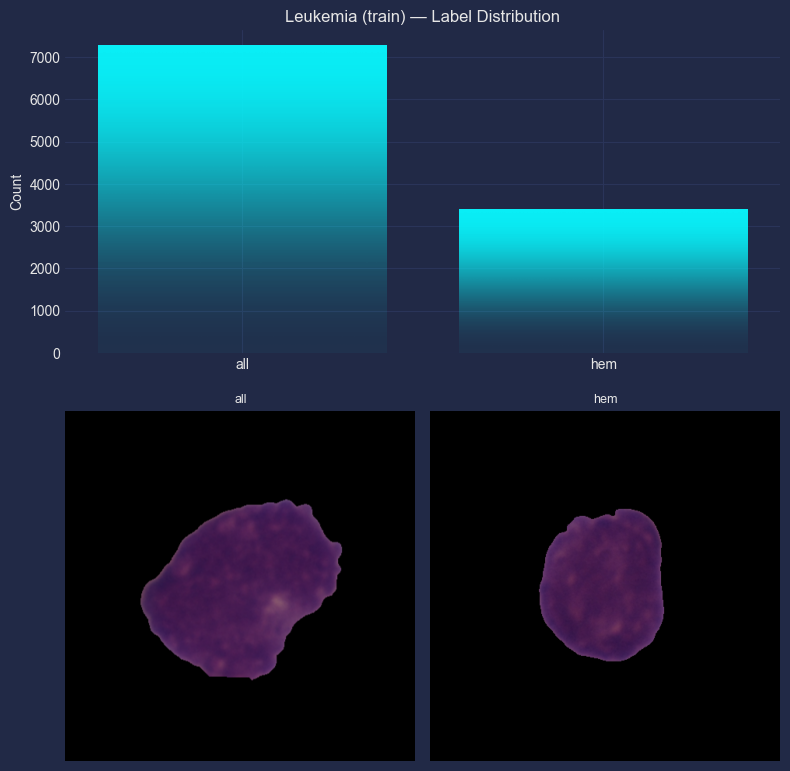

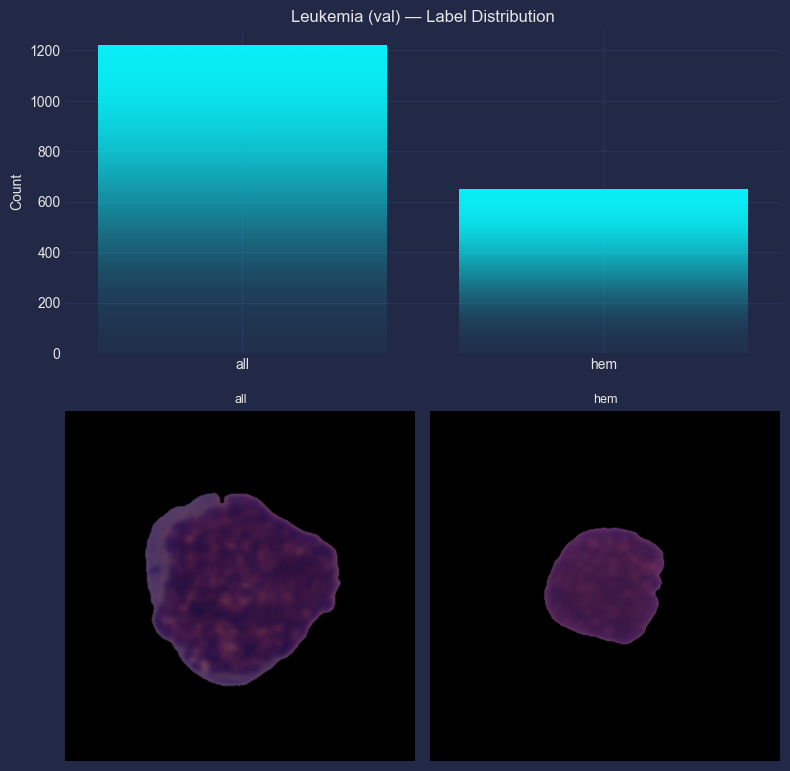

In [30]:
import random, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

try:
    import mplcyberpunk
except ModuleNotFoundError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "mplcyberpunk"])
    import mplcyberpunk

plt.style.use("cyberpunk")

def plot_split_samples(split="train", k_per_class=1):
    """
    Cyberpunk bar chart + example image(s) per class for the chosen split.
    split: "train", "val", or "test"
    k_per_class: number of random samples to show per class (1 = like your example)
    """
    csv_path = SPLIT_DIR / f"{split}.csv"
    df = pd.read_csv(csv_path)

    counts = [int((df["label"] == i).sum()) for i in range(num_classes)]


    per_class_paths = []
    for i in range(num_classes):
        paths = (REPO_ROOT / df.loc[df["label"] == i, "path"]).tolist()
        if len(paths) == 0:
            per_class_paths.append([])
        else:
            random.shuffle(paths)
            per_class_paths.append(paths[:k_per_class])

    cols = len(class_names) * k_per_class
    fig = plt.figure(figsize=(min(18, 6 + 2 * k_per_class), 8))
    gs = fig.add_gridspec(nrows=2, ncols=len(class_names), height_ratios=[1.0, 1.2])

    ax_bar = fig.add_subplot(gs[0, :])
    xpos = np.arange(len(class_names))
    bars = ax_bar.bar(xpos, counts)
    mplcyberpunk.add_bar_gradient(bars=bars)
    mplcyberpunk.make_lines_glow(ax=ax_bar)
    ax_bar.set_xticks(xpos, class_names)
    ax_bar.set_ylabel("Count")
    ax_bar.set_title(f"Leukemia ({split}) — Label Distribution")


    for i, cls in enumerate(class_names):
        ax = fig.add_subplot(gs[1, i])
        ax.set_title(cls, fontsize=9)
        ax.axis("off")
        ys = per_class_paths[i]
        if ys:
            if k_per_class == 1:
                img = Image.open(ys[0]).convert("RGB")
                ax.imshow(img)
            else:
                
                n = len(ys)
                for r, p in enumerate(ys):
                    img = Image.open(p).convert("RGB")
                    ax_in = ax.inset_axes([0, 1 - (r+1)/n, 1, 1/n])
                    ax_in.imshow(img); ax_in.axis("off")

    fig.tight_layout()
    plt.show()


plot_split_samples("train", k_per_class=1)   
plot_split_samples("val",   k_per_class=1)   

In [31]:
from collections import Counter
from torch.cuda.amp import autocast, GradScaler



In [32]:
cnt = Counter(pd.read_csv(SPLIT_DIR/"train.csv")["label"].tolist())
freqs = np.array([cnt.get(i, 0) for i in range(num_classes)], dtype=float)
weights = (1.0 / (freqs + 1e-9)); weights = weights / weights.sum() * num_classes
class_weights = torch.tensor(weights, dtype=torch.float32, device=device)
print("train counts:", cnt, "\nclass_weights:", class_weights.cpu().numpy())


train counts: Counter({0: 7272, 1: 3389}) 
class_weights: [0.63577527 1.3642248 ]


In [38]:
cnn = tvm.resnet18(weights=ResNet18_Weights.DEFAULT)
cnn.fc = nn.Linear(cnn.fc.in_features, num_classes)
cnn = cnn.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
base_lr   = 3e-4 * (batch_size / 32)
optimizer = optim.AdamW(cnn.parameters(), lr=base_lr, weight_decay=1e-4)
epochs    = 20
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
scaler    = GradScaler(enabled=torch.cuda.is_available())

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10980\2067860479.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler(enabled=torch.cuda.is_available())


In [39]:
def run_epoch(model, loader, train=True):
    model.train(train)
    loss_sum = 0.0
    logits_all, targets_all = [], []
    for x, y in tqdm(loader, leave=False):
        x = x.to(device, non_blocking=True)
        y = torch.as_tensor(y, device=device)

        if train:
            optimizer.zero_grad(set_to_none=True)
            with autocast(enabled=torch.cuda.is_available()):
                logits = model(x); loss = criterion(logits, y)
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        else:
            with torch.no_grad(), autocast(enabled=torch.cuda.is_available()):
                logits = model(x); loss = criterion(logits, y)

        loss_sum += loss.item() * x.size(0)
        logits_all.append(logits.detach().float().cpu())
        targets_all.append(y.detach().long().cpu())

    loss_epoch = loss_sum / len(loader.dataset)
    logits_all = torch.cat(logits_all); targets_all = torch.cat(targets_all)
    auroc = MulticlassAUROC(num_classes=num_classes, average="macro")(logits_all.softmax(1), targets_all).item()
    acc   = MulticlassAccuracy(num_classes=num_classes, average="macro")(logits_all.argmax(1), targets_all).item()
    return loss_epoch, acc, auroc

In [40]:
def fit_cnn(epochs=20, ckpt="cls_leukemia_resnet18.pt"):
    CKPT_DIR = REPO_ROOT / "checkpoints" / "classification"; CKPT_DIR.mkdir(parents=True, exist_ok=True)
    MET_DIR  = REPO_ROOT / "results" / "metrics";          MET_DIR.mkdir(parents=True, exist_ok=True)
    best = -1.0; hist = []
    for ep in range(1, epochs+1):
        tr_loss, tr_acc, tr_auc = run_epoch(cnn, train_loader, True)
        va_loss, va_acc, va_auc = run_epoch(cnn, val_loader,   False)
        scheduler.step()
        hist.append({"epoch":ep,"train_loss":tr_loss,"train_acc":tr_acc,"train_auroc":tr_auc,
                     "val_loss":va_loss,"val_acc":va_acc,"val_auroc":va_auc,"lr":scheduler.get_last_lr()[0]})
        print(f"[{ep:03d}] train: loss {tr_loss:.4f} acc {tr_acc:.3f} auc {tr_auc:.3f} | "
              f"val: loss {va_loss:.4f} acc {va_acc:.3f} auc {va_auc:.3f}")
        if va_auc > best:
            best = va_auc
            torch.save({"state_dict": cnn.state_dict(),
                        "class_names": class_names,
                        "num_classes": num_classes,
                        "model_name": "resnet18"},
                       CKPT_DIR / ckpt)
    with open(MET_DIR / "leukemia_resnet18_history.json", "w") as f:
        json.dump(hist, f, indent=2)
    print("Best val AUROC:", best)


In [42]:
from collections import Counter
cnt = Counter(pd.read_csv(SPLIT_DIR/"train.csv")["label"].tolist())
print("counts:", cnt)
print("num_classes:", num_classes, "class_names:", class_names)

freqs = np.array([cnt.get(i,0) for i in range(num_classes)], dtype=float)
print("freqs:", freqs, "has_zero?", (freqs==0).any())


counts: Counter({0: 7272, 1: 3389})
num_classes: 2 class_names: ['all', 'hem']
freqs: [7272. 3389.] has_zero? False


In [43]:
xb, yb = next(iter(train_loader))
xb = xb.to(device, non_blocking=True)
yb = torch.as_tensor(yb, device=device)

print("xb finite?", torch.isfinite(xb).all().item(), xb.min().item(), xb.max().item())
cnn.eval()
with torch.no_grad():
    logits = cnn(xb)
print("logits finite?", torch.isfinite(logits).all().item(),
      "min:", logits.min().item(), "max:", logits.max().item())

xb finite? True -2.1179039478302 0.4090632498264313
logits finite? False min: nan max: nan


In [45]:
import torch.nn as nn
from torchvision import models as tvm
from torchvision.models import ResNet18_Weights

def build_resnet18_fresh(num_classes):
    m = tvm.resnet18(weights=ResNet18_Weights.DEFAULT)  
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m.to(device)


del cnn
torch.cuda.empty_cache()

cnn = build_resnet18_fresh(num_classes)
cnn.eval()

def check_model_finite(model):
    bad = []
    for n,p in model.named_parameters():
        if not torch.isfinite(p).all():
            bad.append(("param", n))
    for n,b in model.named_buffers():
        if not torch.isfinite(b).all():
            bad.append(("buffer", n))
    return bad

bad = check_model_finite(cnn)
print("non-finite tensors:", bad)   # should be []

xb, yb = next(iter(train_loader))
xb = xb.to(device, non_blocking=True)
with torch.no_grad():
    logits = cnn(xb)
print("logits finite now?", torch.isfinite(logits).all().item())


non-finite tensors: []
logits finite now? True


In [46]:
import torch.nn as nn, torch.optim as optim
from torchmetrics.classification import MulticlassAUROC, MulticlassAccuracy
from tqdm.auto import tqdm

criterion = nn.CrossEntropyLoss()

base_lr = 1e-4 * (batch_size / 32)
optimizer = optim.AdamW(cnn.parameters(), lr=base_lr, weight_decay=1e-4)
epochs    = 20
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

def run_epoch_fp32(loader, train=True):
    cnn.train(train)
    loss_sum = 0.0
    logits_all, targets_all = [], []

    for x, y in tqdm(loader, leave=False):
        x = x.to(device, non_blocking=True)
        y = torch.as_tensor(y, device=device)

        if train:
            optimizer.zero_grad(set_to_none=True)
            logits = cnn(x)
            loss   = criterion(logits, y)

            if not torch.isfinite(loss):
                print("⚠️ non-finite loss; skipping batch"); 
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(cnn.parameters(), 1.0)
            optimizer.step()
        else:
            with torch.no_grad():
                logits = cnn(x); loss = criterion(logits, y)

        loss_sum += loss.item() * x.size(0)
        logits_all.append(logits.detach().float().cpu())
        targets_all.append(y.detach().long().cpu())

    loss_epoch = loss_sum / len(loader.dataset)
    logits_all = torch.cat(logits_all); targets_all = torch.cat(targets_all)
    auroc = MulticlassAUROC(num_classes=num_classes, average="macro")(logits_all.softmax(1), targets_all).item()
    acc   = MulticlassAccuracy(num_classes=num_classes, average="macro")(logits_all.argmax(1), targets_all).item()
    return loss_epoch, acc, auroc


In [47]:
best = -1.0
hist = []
for ep in range(1, epochs+1):
    tr_loss, tr_acc, tr_auc = run_epoch_fp32(train_loader, True)
    va_loss, va_acc, va_auc = run_epoch_fp32(val_loader,   False)
    scheduler.step()
    hist.append({"epoch":ep,"train_loss":tr_loss,"train_acc":tr_acc,"train_auroc":tr_auc,
                 "val_loss":va_loss,"val_acc":va_acc,"val_auroc":va_auc,"lr":scheduler.get_last_lr()[0]})
    print(f"[{ep:03d}] train: loss {tr_loss:.4f} acc {tr_acc:.3f} auc {tr_auc:.3f} | "
          f"val: loss {va_loss:.4f} acc {va_acc:.3f} auc {va_auc:.3f}")

    if va_auc > best:
        best = va_auc
        (REPO_ROOT/"checkpoints"/"classification").mkdir(parents=True, exist_ok=True)
        torch.save({"state_dict": cnn.state_dict(),
                    "class_names": class_names,
                    "num_classes": num_classes,
                    "model_name": "resnet18"},
                   REPO_ROOT/"checkpoints"/"classification"/"cls_leukemia_resnet18.pt")

print("Best val AUROC:", best)

  0%|          | 0/334 [00:00<?, ?it/s]

  0%|          | 0/59 [00:00<?, ?it/s]

[001] train: loss 0.3180 acc 0.838 auc 0.917 | val: loss 0.6770 acc 0.589 auc 0.692


  0%|          | 0/334 [00:00<?, ?it/s]

  0%|          | 0/59 [00:00<?, ?it/s]

...

  0%|          | 0/59 [00:00<?, ?it/s]

[019] train: loss 0.0136 acc 0.993 auc 1.000 | val: loss 1.1824 acc 0.742 auc 0.866


  0%|          | 0/334 [00:00<?, ?it/s]

  0%|          | 0/59 [00:00<?, ?it/s]

[020] train: loss 0.0172 acc 0.992 auc 1.000 | val: loss 1.1661 acc 0.734 auc 0.850
Best val AUROC: 0.8911622166633606
